# Using Machine Learning techniques to predict a stroke

## Imports

In [190]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report
from sklearn.base import clone
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

## Load in data, basic data information

In [191]:
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

file_path = os.path.join(path, "healthcare-dataset-stroke-data.csv")
df = pd.read_csv(file_path)

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [192]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


## Data cleaning

In [193]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

### Checking data for unique values

Before modifying the data to be fit for training we should check how many unique values each feature can have, so that we can determine how to represent it (eg. use 0 and 1 for yes-no columns or one-hot encoding for those with more posiible values).

In [194]:
for column in df.columns:
    print(f"{column} values: {df[column].unique()}")

id values: [ 9046 51676 31112 ... 19723 37544 44679]
gender values: ['Male' 'Female' 'Other']
age values: [6.70e+01 6.10e+01 8.00e+01 4.90e+01 7.90e+01 8.10e+01 7.40e+01 6.90e+01
 5.90e+01 7.80e+01 5.40e+01 5.00e+01 6.40e+01 7.50e+01 6.00e+01 5.70e+01
 7.10e+01 5.20e+01 8.20e+01 6.50e+01 5.80e+01 4.20e+01 4.80e+01 7.20e+01
 6.30e+01 7.60e+01 3.90e+01 7.70e+01 7.30e+01 5.60e+01 4.50e+01 7.00e+01
 6.60e+01 5.10e+01 4.30e+01 6.80e+01 4.70e+01 5.30e+01 3.80e+01 5.50e+01
 1.32e+00 4.60e+01 3.20e+01 1.40e+01 3.00e+00 8.00e+00 3.70e+01 4.00e+01
 3.50e+01 2.00e+01 4.40e+01 2.50e+01 2.70e+01 2.30e+01 1.70e+01 1.30e+01
 4.00e+00 1.60e+01 2.20e+01 3.00e+01 2.90e+01 1.10e+01 2.10e+01 1.80e+01
 3.30e+01 2.40e+01 3.40e+01 3.60e+01 6.40e-01 4.10e+01 8.80e-01 5.00e+00
 2.60e+01 3.10e+01 7.00e+00 1.20e+01 6.20e+01 2.00e+00 9.00e+00 1.50e+01
 2.80e+01 1.00e+01 1.80e+00 3.20e-01 1.08e+00 1.90e+01 6.00e+00 1.16e+00
 1.00e+00 1.40e+00 1.72e+00 2.40e-01 1.64e+00 1.56e+00 7.20e-01 1.88e+00
 1.24e+00 8.00e-01

### Adjusting column types

In [195]:
df["age"] = df["age"].astype("uint8")
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


### Checking for NaN values

We check if there are any values missing from the dataset.
- `df.isna()` – returns a DataFrame of True/False values (True if the value in the original DataFrame is NaN, False otherwise)  
- `df.isna().any()` – for each column, checks if it contains at least one True value  
- `df.isna().any().any()` – returns True if there is **at least one NaN** in the original DataFrame, False otherwise

In [196]:
df.isna().any().any()

np.True_

### Dealing with NaNs

BMI is the only columns with missing values. We fill them using the gender average.

In [197]:
df["bmi"] = df["bmi"].fillna(df.groupby("gender")["bmi"].transform("mean"))
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61,0,0,Yes,Self-employed,Rural,202.21,29.065758,never smoked,1
2,31112,Male,80,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80,1,0,Yes,Private,Urban,83.75,29.065758,never smoked,0
5106,44873,Female,81,0,0,Yes,Self-employed,Urban,125.20,40.000000,never smoked,0
5107,19723,Female,35,0,0,Yes,Self-employed,Rural,82.99,30.600000,never smoked,0
5108,37544,Male,51,0,0,Yes,Private,Rural,166.29,25.600000,formerly smoked,0


### Modifying the data

In [198]:
# Binary to 1/0
df["ever_married"] = df["ever_married"].map({"Yes": 1, "No": 0})

# One-Hot Encoding
df = pd.get_dummies(df, columns=["gender", "work_type", "Residence_type", "smoking_status"])

# Convert all bool columns from OHE to int
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

df.head()

,id,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,9046,67,0,1,1,228.69,36.600000,1,0,1,...,0,1,0,0,0,1,0,1,0,0
1,51676,61,0,0,1,202.21,29.065758,1,1,0,...,0,0,1,0,1,0,0,0,1,0
2,31112,80,0,1,1,105.92,32.500000,1,0,1,...,0,1,0,0,1,0,0,0,1,0
3,60182,49,0,0,1,171.23,34.400000,1,1,0,...,0,1,0,0,0,1,0,0,0,1
4,1665,79,1,0,1,174.12,24.000000,1,1,0,...,0,0,1,0,1,0,0,0,1,0


In [199]:
# Move label to the rightmost side of the dataframe
cols = [c for c in df.columns if c != "stroke"] + ["stroke"]
df = df[cols]

### Renaming the columns

In this step we standardize the naming convention of features in the dataframe.

In [200]:
def get_renamed_column(name):
    name = name.strip()
    name = name.lower()
    name = name.replace(" ", "_")

    return name


def get_rename_dict(column_names):
    rename_dict = {}
    for name in column_names:
        rename_dict[name] = get_renamed_column(name)

    return rename_dict

In [201]:
df = df.rename(columns=get_rename_dict(df.columns))
df.head()

,id,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,gender_female,gender_male,gender_other,...,work_type_private,work_type_self-employed,work_type_children,residence_type_rural,residence_type_urban,smoking_status_unknown,smoking_status_formerly_smoked,smoking_status_never_smoked,smoking_status_smokes,stroke
0,9046,67,0,1,1,228.69,36.600000,0,1,0,...,1,0,0,0,1,0,1,0,0,1
1,51676,61,0,0,1,202.21,29.065758,1,0,0,...,0,1,0,1,0,0,0,1,0,1
2,31112,80,0,1,1,105.92,32.500000,0,1,0,...,1,0,0,1,0,0,0,1,0,1
3,60182,49,0,0,1,171.23,34.400000,1,0,0,...,1,0,0,0,1,0,0,0,1,1
4,1665,79,1,0,1,174.12,24.000000,1,0,0,...,0,1,0,1,0,0,0,1,0,1


### Check for duplicates

In [202]:
any(df.duplicated())

False

There are only unique records in the dataset already, we may proceed.

### Check for class imbalance

Ideally here should be a similar number of records in each class.

In [203]:
df[df.columns[-1]].sum() / df[df.columns[-1]].size

np.float64(0.0487279843444227)

Since stroke was confirmed only in 5% of patients we will use a few different techniques deal with the imbalance.

## Preparing the train and test sets

### Train-test split

In [204]:
print(df.columns)

Index(['id', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'avg_glucose_level', 'bmi', 'gender_female', 'gender_male',
       'gender_other', 'work_type_govt_job', 'work_type_never_worked',
       'work_type_private', 'work_type_self-employed', 'work_type_children',
       'residence_type_rural', 'residence_type_urban',
       'smoking_status_unknown', 'smoking_status_formerly_smoked',
       'smoking_status_never_smoked', 'smoking_status_smokes', 'stroke'],
      dtype='object')


### Dropping features

In [205]:
columns_to_drop = ["id", "ever_married", "gender_female", "gender_male", "gender_other", "work_type_govt_job", "work_type_never_worked",
       "work_type_private", "work_type_self-employed", "work_type_children"]
df = df.drop(columns=columns_to_drop)

In [206]:
X = df.drop(columns=[df.columns[-1]]) 
y = df[df.columns[-1]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Data visualization

### Correlation matrix

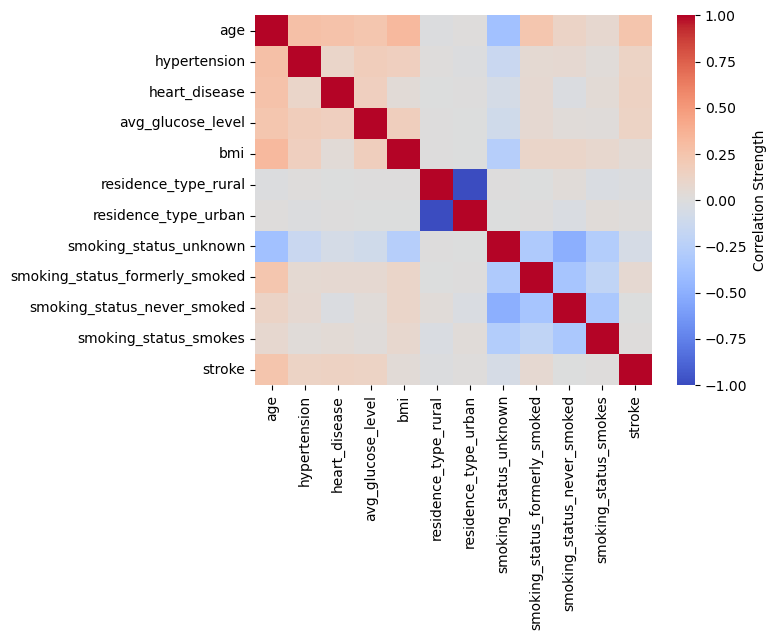

In [207]:
corr = df.corr(numeric_only=True)
ax = sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, cbar=True)

cbar = ax.collections[0].colorbar
cbar.set_label("Correlation Strength")

plt.show()

## Create models

### Random Forests

In [208]:
random_forest_models = {
    "RandomForest_100_5": RandomForestClassifier(
        n_estimators=100,
        max_depth=5
    ),
    "RandomForest_50_5": RandomForestClassifier(
        n_estimators=50,
        max_depth=5
    ),
    "RandomForest_50_10": RandomForestClassifier(
        n_estimators=50,
        max_depth=10
    ),
    "RandomForest_500_3": RandomForestClassifier(
        n_estimators=500,
        max_depth=3
    ),
    "RandomForest_200_10": RandomForestClassifier(
        n_estimators=200,
        max_depth=10
    ),
    "RandomForest_300_7": RandomForestClassifier(
        n_estimators=300,
        max_depth=7
    ),
}

### XGBoost

In [209]:
xgboost_models = {
    "XGBoost_100_5_10": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        scale_pos_weight=10
    ),
    "XGBoost_50_5_10": XGBClassifier(
        n_estimators=50,
        learning_rate=0.2,
        max_depth=5,
        scale_pos_weight=10
    ),
    "XGBoost_100_10_5": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=10,
        scale_pos_weight=5
    ),
    "XGBoost_150_7_10": XGBClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=7,
        scale_pos_weight=10
    ),
    "XGBoost_80_15_5": XGBClassifier(
        n_estimators=80,
        learning_rate=0.3,
        max_depth=15,
        scale_pos_weight=5
    ),
    "XGBoost_200_8_8": XGBClassifier(
        n_estimators=200,
        learning_rate=0.02,
        max_depth=8,
        scale_pos_weight=8
    )
}

### Neural Networks

In [210]:
input_shape = X_train.shape[1]

neural_networks_models = {
    "NN_64_32_1": Sequential([
        Dense(64, activation="relu", input_shape=(input_shape,)),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ]),
    "NN_32_32_32_1": Sequential([
        Dense(32, activation="sigmoid", input_shape=(input_shape,)),
        Dense(32, activation="sigmoid"),
        Dense(32, activation="sigmoid"),
        Dense(1, activation="sigmoid")
    ]),
    "NN_64_64_1": Sequential([
        Dense(64, activation="relu", input_shape=(input_shape,)),
        Dense(64, activation="tanh"),
        Dense(1, activation="sigmoid")
    ]),
    "NN_128_64_64_1": Sequential([
        Dense(128, activation="relu", input_shape=(input_shape,)),
        Dense(64, activation="relu"),
        Dense(64, activation="relu"),
        Dense(1, activation="sigmoid")
    ]),
    "NN_64_1": Sequential([
        Dense(64, activation="relu", input_shape=(input_shape,)),
        Dense(1, activation="sigmoid")
    ]),
    "NN_64_32_64_1": Sequential([
        Dense(64, activation="relu", input_shape=(input_shape,)),
        Dense(32, activation="tanh"),
        Dense(64, activation="tanh"),
        Dense(1, activation="sigmoid")
    ]),
}

c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Train models

#### Printing results functions

In [211]:
def print_validate_models(results):
    for name, result in results.items():
        print(f"{name}: {result}\n")

def print_trained_models(trained_models):
 
    for name, model in trained_models.items():
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc_roc = roc_auc_score(y_test, y_prob)

        print(f"{name} Accuracy: {accuracy}")
        print(f"{name} Precision: {precision}")
        print(f"{name} Recall: {recall}")
        print(f"{name} F1: {f1}")
        print(f"{name} AUC ROC: {auc_roc}\n")

### Baseline (ignoring the imbalance)

#### Cross-validation pipeline

In [212]:
def validate_models_baseline(models, X, y):
    results = {}

    for name, model in models.items():
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])

        scores = cross_validate(pipeline, X, y, cv=5, scoring=["precision", "recall", "f1"])
        results[name] = {
            "precision": scores["test_precision"].mean(),
            "recall": scores["test_recall"].mean(),
            "f1": scores["test_f1"].mean(),
        }

    return results

#### Training pipeline

In [213]:
def train_models_baseline(models, X, y):

    trained_models = {}

    for name, model in models.items():
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])

        trained_pipeline = pipeline.fit(X, y)
        trained_models[name] = trained_pipeline

    return trained_models


#### Baseline for Random Forest

In [214]:
results = validate_models_baseline(random_forest_models, X_train, y_train)
print_validate_models(results)

c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\D

RandomForest_100_5: {'precision': np.float64(0.0), 'recall': np.float64(0.0), 'f1': np.float64(0.0)}

RandomForest_50_5: {'precision': np.float64(0.0), 'recall': np.float64(0.0), 'f1': np.float64(0.0)}

RandomForest_50_10: {'precision': np.float64(0.0), 'recall': np.float64(0.0), 'f1': np.float64(0.0)}

RandomForest_500_3: {'precision': np.float64(0.0), 'recall': np.float64(0.0), 'f1': np.float64(0.0)}

RandomForest_200_10: {'precision': np.float64(0.0), 'recall': np.float64(0.0), 'f1': np.float64(0.0)}

RandomForest_300_7: {'precision': np.float64(0.0), 'recall': np.float64(0.0), 'f1': np.float64(0.0)}



c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [215]:
trained_models = train_models_baseline(random_forest_models, X_train, y_train)
print_trained_models(trained_models)

c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


RandomForest_100_5 Accuracy: 0.9393346379647749
RandomForest_100_5 Precision: 0.0
RandomForest_100_5 Recall: 0.0
RandomForest_100_5 F1: 0.0
RandomForest_100_5 AUC ROC: 0.8531922043010751

RandomForest_50_5 Accuracy: 0.9393346379647749
RandomForest_50_5 Precision: 0.0
RandomForest_50_5 Recall: 0.0
RandomForest_50_5 F1: 0.0
RandomForest_50_5 AUC ROC: 0.849756384408602

RandomForest_50_10 Accuracy: 0.9403131115459883
RandomForest_50_10 Precision: 1.0
RandomForest_50_10 Recall: 0.016129032258064516
RandomForest_50_10 F1: 0.031746031746031744
RandomForest_50_10 AUC ROC: 0.819489247311828



c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


RandomForest_500_3 Accuracy: 0.9393346379647749
RandomForest_500_3 Precision: 0.0
RandomForest_500_3 Recall: 0.0
RandomForest_500_3 F1: 0.0
RandomForest_500_3 AUC ROC: 0.8511592741935484

RandomForest_200_10 Accuracy: 0.9393346379647749
RandomForest_200_10 Precision: 0.5
RandomForest_200_10 Recall: 0.016129032258064516
RandomForest_200_10 F1: 0.03125
RandomForest_200_10 AUC ROC: 0.8282426075268817

RandomForest_300_7 Accuracy: 0.9393346379647749
RandomForest_300_7 Precision: 0.0
RandomForest_300_7 Recall: 0.0
RandomForest_300_7 F1: 0.0
RandomForest_300_7 AUC ROC: 0.8489415322580645



c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Without using any techniques for dealing with the class imbalance, the Random Forest models did not predict any positive, making precision, recall and F1 impossible to calculate. This outcome shows the importance of using those methods while working with skewed data.

#### Baseline for XGBoost

In [216]:
results = validate_models_baseline(xgboost_models, X_train, y_train)
print_validate_models(results)

XGBoost_100_5_10: {'precision': np.float64(0.17679588274738495), 'recall': np.float64(0.3476529160739687), 'f1': np.float64(0.23352208723176465)}

XGBoost_50_5_10: {'precision': np.float64(0.16471359530532861), 'recall': np.float64(0.3155049786628734), 'f1': np.float64(0.2160965907010813)}

XGBoost_100_10_5: {'precision': np.float64(0.16888801451461297), 'recall': np.float64(0.09061166429587482), 'f1': np.float64(0.11707722453624095)}

XGBoost_150_7_10: {'precision': np.float64(0.1733751802627816), 'recall': np.float64(0.27283072546230447), 'f1': np.float64(0.2111269123033829)}

XGBoost_80_15_5: {'precision': np.float64(0.14114190157668421), 'recall': np.float64(0.058748221906116636), 'f1': np.float64(0.08123456664805698)}

XGBoost_200_8_8: {'precision': np.float64(0.173248130828776), 'recall': np.float64(0.23527738264580372), 'f1': np.float64(0.19780712632585395)}



In [217]:
trained_models = train_models_baseline(xgboost_models, X_train, y_train)
print_trained_models(trained_models)

XGBoost_100_5_10 Accuracy: 0.8904109589041096
XGBoost_100_5_10 Precision: 0.23958333333333334
XGBoost_100_5_10 Recall: 0.3709677419354839
XGBoost_100_5_10 F1: 0.2911392405063291
XGBoost_100_5_10 AUC ROC: 0.8161626344086022

XGBoost_50_5_10 Accuracy: 0.8953033268101761
XGBoost_50_5_10 Precision: 0.25274725274725274
XGBoost_50_5_10 Recall: 0.3709677419354839
XGBoost_50_5_10 F1: 0.3006535947712418
XGBoost_50_5_10 AUC ROC: 0.8194388440860215

XGBoost_100_10_5 Accuracy: 0.9256360078277887
XGBoost_100_10_5 Precision: 0.23076923076923078
XGBoost_100_10_5 Recall: 0.0967741935483871
XGBoost_100_10_5 F1: 0.13636363636363635
XGBoost_100_10_5 AUC ROC: 0.8051747311827957

XGBoost_150_7_10 Accuracy: 0.9001956947162426
XGBoost_150_7_10 Precision: 0.22972972972972974
XGBoost_150_7_10 Recall: 0.27419354838709675
XGBoost_150_7_10 F1: 0.25
XGBoost_150_7_10 AUC ROC: 0.8266801075268817

XGBoost_80_15_5 Accuracy: 0.9275929549902152
XGBoost_80_15_5 Precision: 0.25
XGBoost_80_15_5 Recall: 0.0967741935483871
X

### Using SMOTE to deal with class imbalance

#### Cross-validation pipeline

In [218]:
def validate_models_smote(models, X, y):
    results = {}

    for name, model in models.items():
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("smote", SMOTE(sampling_strategy="minority")),
            ("model", model)
        ])

        scores = cross_validate(pipeline, X, y, cv=5, scoring=["precision", "recall", "f1"])
        results[name] = {
            "precision": scores["test_precision"].mean(),
            "recall": scores["test_recall"].mean(),
            "f1": scores["test_f1"].mean(),
        }

    return results

#### Training pipeline

In [219]:
def train_models_smote(models, X, y):

    trained_models = {}

    for name, model in models.items():
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("smote", SMOTE(sampling_strategy="minority")),
            ("model", model)
        ])

        trained_pipeline = pipeline.fit(X, y)
        trained_models[name] = trained_pipeline

    return trained_models


##### SMOTE + Random Forest

In [220]:
results = validate_models_smote(random_forest_models, X_train, y_train)
print_validate_models(results)

RandomForest_100_5: {'precision': np.float64(0.11622742674572632), 'recall': np.float64(0.7914651493598862), 'f1': np.float64(0.2026211470936738)}

RandomForest_50_5: {'precision': np.float64(0.12113529582268627), 'recall': np.float64(0.7698435277382647), 'f1': np.float64(0.2091779697430353)}

RandomForest_50_10: {'precision': np.float64(0.12159591664268024), 'recall': np.float64(0.47539118065433855), 'f1': np.float64(0.19326488363137528)}

RandomForest_500_3: {'precision': np.float64(0.11111444836351123), 'recall': np.float64(0.8450924608819346), 'f1': np.float64(0.19631343843593513)}

RandomForest_200_10: {'precision': np.float64(0.12047795085349688), 'recall': np.float64(0.45419630156472257), 'f1': np.float64(0.1900020973155993)}

RandomForest_300_7: {'precision': np.float64(0.12298154099143259), 'recall': np.float64(0.662873399715505), 'f1': np.float64(0.20733725146512358)}



In [221]:
trained_models = train_models_smote(random_forest_models, X_train, y_train)
print_trained_models(trained_models)

RandomForest_100_5 Accuracy: 0.726027397260274
RandomForest_100_5 Precision: 0.1550632911392405
RandomForest_100_5 Recall: 0.7903225806451613
RandomForest_100_5 F1: 0.25925925925925924
RandomForest_100_5 AUC ROC: 0.8321656586021506

RandomForest_50_5 Accuracy: 0.7367906066536204
RandomForest_50_5 Precision: 0.15841584158415842
RandomForest_50_5 Recall: 0.7741935483870968
RandomForest_50_5 F1: 0.26301369863013696
RandomForest_50_5 AUC ROC: 0.8282930107526882

RandomForest_50_10 Accuracy: 0.8336594911937377
RandomForest_50_10 Precision: 0.17857142857142858
RandomForest_50_10 Recall: 0.4838709677419355
RandomForest_50_10 F1: 0.2608695652173913
RandomForest_50_10 AUC ROC: 0.8039650537634409

RandomForest_500_3 Accuracy: 0.6800391389432485
RandomForest_500_3 Precision: 0.14092140921409213
RandomForest_500_3 Recall: 0.8387096774193549
RandomForest_500_3 F1: 0.24129930394431554
RandomForest_500_3 AUC ROC: 0.8393145161290322

RandomForest_200_10 Accuracy: 0.8170254403131115
RandomForest_200_10

##### SMOTE + XGBoost

In [222]:
results = validate_models_smote(xgboost_models, X_train, y_train)
print_validate_model_smote(results)

XGBoost_100_5_10: {'precision': np.float64(0.09413490652071496), 'recall': np.float64(0.6849217638691323), 'f1': np.float64(0.16547760049644142)}

XGBoost_50_5_10: {'precision': np.float64(0.091948325959777), 'recall': np.float64(0.6524893314366998), 'f1': np.float64(0.16115946547207785)}

XGBoost_100_10_5: {'precision': np.float64(0.10729776937249717), 'recall': np.float64(0.3745376955903271), 'f1': np.float64(0.1667129058516486)}

XGBoost_150_7_10: {'precision': np.float64(0.09458169950759163), 'recall': np.float64(0.588620199146515), 'f1': np.float64(0.16290787346514693)}

XGBoost_80_15_5: {'precision': np.float64(0.11572581769842975), 'recall': np.float64(0.2837837837837838), 'f1': np.float64(0.16420645590475838)}

XGBoost_200_8_8: {'precision': np.float64(0.09828388112452553), 'recall': np.float64(0.6847795163584638), 'f1': np.float64(0.17179738079831172)}



In [223]:
trained_models = train_models_smote(xgboost_models, X_train, y_train)
print_trained_models(trained_models)

XGBoost_100_5_10 Accuracy: 0.6545988258317026
XGBoost_100_5_10 Precision: 0.11609498680738786
XGBoost_100_5_10 Recall: 0.7096774193548387
XGBoost_100_5_10 F1: 0.19954648526077098
XGBoost_100_5_10 AUC ROC: 0.7617943548387097

XGBoost_50_5_10 Accuracy: 0.6908023483365949
XGBoost_50_5_10 Precision: 0.1286549707602339
XGBoost_50_5_10 Recall: 0.7096774193548387
XGBoost_50_5_10 F1: 0.21782178217821782
XGBoost_50_5_10 AUC ROC: 0.7753192204301076

XGBoost_100_10_5 Accuracy: 0.8033268101761253
XGBoost_100_10_5 Precision: 0.13227513227513227
XGBoost_100_10_5 Recall: 0.4032258064516129
XGBoost_100_10_5 F1: 0.199203187250996
XGBoost_100_10_5 AUC ROC: 0.7606014784946237

XGBoost_150_7_10 Accuracy: 0.6956947162426614
XGBoost_150_7_10 Precision: 0.12612612612612611
XGBoost_150_7_10 Recall: 0.6774193548387096
XGBoost_150_7_10 F1: 0.21265822784810126
XGBoost_150_7_10 AUC ROC: 0.7664986559139785

XGBoost_80_15_5 Accuracy: 0.8610567514677103
XGBoost_80_15_5 Precision: 0.11538461538461539
XGBoost_80_15_5 

### Using Ensemble to deal with class imbalance

In [ ]:
ensemble_set = pd.concat((X_train.copy(), y_train.copy()), axis="columns")

# Divide the ensemble set by the label
ensemble_class_0 = ensemble_set[ensemble_set[ensemble_set.columns[-1]] == 0]
ensemble_class_1 = ensemble_set[ensemble_set[ensemble_set.columns[-1]] == 1]

# Create train and test sets
X_train_class_0 = ensemble_class_0.drop(ensemble_class_0.columns[-1], axis="columns")
y_train_class_0 = ensemble_class_0[ensemble_class_0.columns[-1]]

X_train_class_1 = ensemble_class_1.drop(ensemble_class_1.columns[-1], axis="columns")
y_train_class_1 = ensemble_class_1[ensemble_class_1.columns[-1]]

# Estimate the number of sub models required and the numer of class 0 records per each sub model
sub_models_count = int(len(X_train_class_0) / len(X_train_class_1))
records_per_set = len(X_train_class_0) // sub_models_count


In [ ]:
def create_ensemble_model(models):
    ensemble_models = {}
    for name, model in models.items():
        ensemble_model = []
        for i in range(sub_models_count):
            X_chunk = X_train_class_0.sample(n=records_per_set, replace=True)
            y_chunk = y_train_class_0.loc[X_chunk.index]
            current_X_train = pd.concat((X_chunk, X_train_class_1), axis="rows")
            current_y_train = pd.concat((y_chunk, y_train_class_1), axis="rows")

            trained_model = clone(model)
            trained_model.fit(current_X_train, current_y_train)
            ensemble_model.append(trained_model)

        ensemble_models[name] = ensemble_model

    return ensemble_models

In [225]:
for name, model in ensemble_models.items():
    votes = np.zeros(len(X_test))

    for sub_model in model:
        prob = sub_model.predict_proba(X_test)[:, 1]
        votes += prob

    avg_prob = votes / len(model)
    auc_roc = roc_auc_score(y_test, avg_prob)

    thresholds = np.linspace(0.01, 0.9, 50)
    for threshold in thresholds:
        print(f"CURRENT THRESHOLD: {threshold}")
        y_pred = (avg_prob > threshold).astype(int)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        print(f"{name} Accuracy: {accuracy}")
        print(f"{name} Precision: {precision}")
        print(f"{name} Recall: {recall}")
        print(f"{name} F1: {f1}")
    print(f"{name} AUC ROC: {auc_roc}\n")

CURRENT THRESHOLD: 0.01
RandomForest_100_5 Accuracy: 0.060665362035225046
RandomForest_100_5 Precision: 0.060665362035225046
RandomForest_100_5 Recall: 1.0
RandomForest_100_5 F1: 0.11439114391143912
CURRENT THRESHOLD: 0.028163265306122447
RandomForest_100_5 Accuracy: 0.060665362035225046
RandomForest_100_5 Precision: 0.060665362035225046
RandomForest_100_5 Recall: 1.0
RandomForest_100_5 F1: 0.11439114391143912
CURRENT THRESHOLD: 0.0463265306122449
RandomForest_100_5 Accuracy: 0.09197651663405088
RandomForest_100_5 Precision: 0.06262626262626263
RandomForest_100_5 Recall: 1.0
RandomForest_100_5 F1: 0.11787072243346007
CURRENT THRESHOLD: 0.06448979591836734
RandomForest_100_5 Accuracy: 0.13111545988258316
RandomForest_100_5 Precision: 0.06526315789473684
RandomForest_100_5 Recall: 1.0
RandomForest_100_5 F1: 0.1225296442687747
CURRENT THRESHOLD: 0.08265306122448979
RandomForest_100_5 Accuracy: 0.1643835616438356
RandomForest_100_5 Precision: 0.06768558951965066
RandomForest_100_5 Recall: 

c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


RandomForest_100_5 Accuracy: 0.9393346379647749
RandomForest_100_5 Precision: 0.0
RandomForest_100_5 Recall: 0.0
RandomForest_100_5 F1: 0.0
RandomForest_100_5 AUC ROC: 0.8538306451612904

CURRENT THRESHOLD: 0.01
RandomForest_50_5 Accuracy: 0.060665362035225046
RandomForest_50_5 Precision: 0.060665362035225046
RandomForest_50_5 Recall: 1.0
RandomForest_50_5 F1: 0.11439114391143912
CURRENT THRESHOLD: 0.028163265306122447
RandomForest_50_5 Accuracy: 0.060665362035225046
RandomForest_50_5 Precision: 0.060665362035225046
RandomForest_50_5 Recall: 1.0
RandomForest_50_5 F1: 0.11439114391143912
CURRENT THRESHOLD: 0.0463265306122449
RandomForest_50_5 Accuracy: 0.09099804305283757
RandomForest_50_5 Precision: 0.06256306760847628
RandomForest_50_5 Recall: 1.0
RandomForest_50_5 F1: 0.1177587844254511
CURRENT THRESHOLD: 0.06448979591836734
RandomForest_50_5 Accuracy: 0.13209393346379647
RandomForest_50_5 Precision: 0.06533192834562697
RandomForest_50_5 Recall: 1.0
RandomForest_50_5 F1: 0.1226508407

c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


CURRENT THRESHOLD: 0.01
RandomForest_50_10 Accuracy: 0.07436399217221135
RandomForest_50_10 Precision: 0.061507936507936505
RandomForest_50_10 Recall: 1.0
RandomForest_50_10 F1: 0.11588785046728972
CURRENT THRESHOLD: 0.028163265306122447
RandomForest_50_10 Accuracy: 0.1350293542074364
RandomForest_50_10 Precision: 0.06553911205073996
RandomForest_50_10 Recall: 1.0
RandomForest_50_10 F1: 0.12301587301587301
CURRENT THRESHOLD: 0.0463265306122449
RandomForest_50_10 Accuracy: 0.19667318982387474
RandomForest_50_10 Precision: 0.07021517553793885
RandomForest_50_10 Recall: 1.0
RandomForest_50_10 F1: 0.1312169312169312
CURRENT THRESHOLD: 0.06448979591836734
RandomForest_50_10 Accuracy: 0.2700587084148728
RandomForest_50_10 Precision: 0.07673267326732673
RandomForest_50_10 Recall: 1.0
RandomForest_50_10 F1: 0.1425287356321839
CURRENT THRESHOLD: 0.08265306122448979
RandomForest_50_10 Accuracy: 0.324853228962818
RandomForest_50_10 Precision: 0.08244680851063829
RandomForest_50_10 Recall: 1.0
Ran

c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\D

RandomForest_500_3 Accuracy: 0.9393346379647749
RandomForest_500_3 Precision: 0.0
RandomForest_500_3 Recall: 0.0
RandomForest_500_3 F1: 0.0
CURRENT THRESHOLD: 0.8455102040816326
RandomForest_500_3 Accuracy: 0.9393346379647749
RandomForest_500_3 Precision: 0.0
RandomForest_500_3 Recall: 0.0
RandomForest_500_3 F1: 0.0
CURRENT THRESHOLD: 0.863673469387755
RandomForest_500_3 Accuracy: 0.9393346379647749
RandomForest_500_3 Precision: 0.0
RandomForest_500_3 Recall: 0.0
RandomForest_500_3 F1: 0.0
CURRENT THRESHOLD: 0.8818367346938776
RandomForest_500_3 Accuracy: 0.9393346379647749
RandomForest_500_3 Precision: 0.0
RandomForest_500_3 Recall: 0.0
RandomForest_500_3 F1: 0.0
CURRENT THRESHOLD: 0.9
RandomForest_500_3 Accuracy: 0.9393346379647749
RandomForest_500_3 Precision: 0.0
RandomForest_500_3 Recall: 0.0
RandomForest_500_3 F1: 0.0
RandomForest_500_3 AUC ROC: 0.8502856182795698

CURRENT THRESHOLD: 0.01
RandomForest_200_10 Accuracy: 0.08414872798434442
RandomForest_200_10 Precision: 0.062124248

### Using class weight to deal with the imbalance

#### Training Neural Networks

In [226]:
def train_neural_networks(models, X, y):
    results = {}

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    for name, model in models.items():
        model_copy = clone_model(model)
        model_copy.set_weights(model.get_weights()) 
        
        model_copy.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["precision", "recall"])
        model_copy.fit(X_scaled, y, epochs=50, batch_size=32, verbose=0, class_weight={0: 1, 1: 19}, validation_split=0.2)

        results[name] = model_copy

    return results, scaler

In [227]:
trained_models, scaler = train_neural_networks(neural_networks_models, X_train, y_train)
X_test_scaled = scaler.transform(X_test)

for name, model in trained_models.items():
    y_prob = model.predict(X_test_scaled).flatten()
    auc_roc = roc_auc_score(y_test, y_prob)

    thresholds = np.linspace(0.01, 0.9, 50)
    for threshold in thresholds:
        print(f"CURRENT THRESHOLD: {threshold}")
        y_pred = (y_prob > threshold).astype(int) 

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        print(f"{name} Accuracy: {accuracy}")
        print(f"{name} Precision: {precision}")
        print(f"{name} Recall: {recall}")
        print(f"{name} F1: {f1}")
    print(f"{name} AUC ROC: {auc_roc}\n")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
CURRENT THRESHOLD: 0.01
NN_64_32_1 Accuracy: 0.34833659491193736
NN_64_32_1 Precision: 0.0817174515235457
NN_64_32_1 Recall: 0.9516129032258065
NN_64_32_1 F1: 0.15051020408163265
CURRENT THRESHOLD: 0.028163265306122447
NN_64_32_1 Accuracy: 0.4217221135029354
NN_64_32_1 Precision: 0.09119010819165378
NN_64_32_1 Recall: 0.9516129032258065
NN_64_32_1 F1: 0.16643159379407615
CURRENT THRESHOLD: 0.0463265306122449
NN_64_32_1 Accuracy: 0.4628180039138943
NN_64_32_1 Precision: 0.09348914858096828
NN_64_32_1 Recall: 0.9032258064516129
NN_64_32_1 F1: 0.16944024205748864
CURRENT THRESHOLD: 0.06448979591836734
NN_64_32_1 Accuracy: 0.5019569471624267
NN_64_32_1 Precision: 0.1001788908765653
NN_64_32_1 Recall: 0.9032258064516129
NN_64_32_1 F1: 0.18035426731078905
CURRENT THRESHOLD: 0.08265306122448979
NN_64_32_1 Accuracy: 0.5332681017612525
NN_64_32_1 Precision: 0.1062618595825427
NN_64_32_1 Recall: 0.9032258064516129
NN_64_32_1 F1: 0.19015280135823429
CURRENT 

c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
CURRENT THRESHOLD: 0.01
NN_64_64_1 Accuracy: 0.2690802348336595
NN_64_64_1 Precision: 0.07558859975216853
NN_64_64_1 Recall: 0.9838709677419355
NN_64_64_1 F1: 0.14039125431530494
CURRENT THRESHOLD: 0.028163265306122447
NN_64_64_1 Accuracy: 0.3747553816046967
NN_64_64_1 Precision: 0.08489208633093526
NN_64_64_1 Recall: 0.9516129032258065
NN_64_64_1 F1: 0.15587846763540292
CURRENT THRESHOLD: 0.0463265306122449
NN_64_64_1 Accuracy: 0.42857142857142855
NN_64_64_1 Precision: 0.0921875
NN_64_64_1 Recall: 0.9516129032258065
NN_64_64_1 F1: 0.16809116809116809
CURRENT THRESHOLD: 0.06448979591836734
NN_64_64_1 Accuracy: 0.47162426614481406
NN_64_64_1 Precision: 0.09628378378378379
NN_64_64_1 Recall: 0.9193548387096774
NN_64_64_1 F1: 0.1743119266055046
CURRENT THRESHOLD: 0.08265306122448979
NN_64_64_1 Accuracy: 0.5058708414872799
NN_64_64_1 Precision: 0.10233393177737882
NN_64_64_1 Recall: 0.9193548387096774
NN_64_64_1 F1: 0.1841680129240711
CURRENT THRESHOL